<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows',100)
pd.set_option('display.max_columns',8)

In [ ]:
df=pd.read_csv('StudentsPerformance.csv')

In [ ]:
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.size

8000

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [ ]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
df.isnull()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df['gender'].value_counts()

,count
gender,
female,518
male,482


In [ ]:
df['race/ethnicity'].value_counts()

,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


In [ ]:
df['parental level of education'].value_counts()

,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


In [ ]:
df['lunch'].value_counts()

,count
lunch,
standard,645
free/reduced,355


In [ ]:
df[['test preparation course']].value_counts()

,count
test preparation course,
none,642
completed,358


In [ ]:
#df['math score'].value_counts()


In [ ]:
#df['reading score'].value_counts()


In [ ]:
#df['writing score'].value_counts()


In [ ]:
#1. Summary Statistics:
#Calculate mean, median, mode, and standard deviation for numeric columns (math score, reading score, writing score).


mean=df[['math score','reading score','writing score']].mean()
mean

,0
math score,66.089
reading score,69.169
writing score,68.054


In [ ]:
median=df[['math score','reading score','writing score']].median()
median

,0
math score,66.0
reading score,70.0
writing score,69.0


In [ ]:
mode = df[["math score", "reading score", "writing score"]].mode().iloc[0]
mode

,0
math score,65
reading score,72
writing score,74


In [ ]:
std_dev = df[["math score", "reading score", "writing score"]].std()
std_dev

,0
math score,15.163080
reading score,14.600192
writing score,15.195657


In [ ]:
#2. Target Identification:
#Problem: Predicting scores, identifying factors affecting performance.


In [ ]:
df.min()

,0
gender,female
race/ethnicity,group A
parental level of education,associate's degree
lunch,free/reduced
test preparation course,completed
math score,0
reading score,17
writing score,10


In [ ]:
df.max()

,0
gender,male
race/ethnicity,group E
parental level of education,some high school
lunch,standard
test preparation course,none
math score,100
reading score,100
writing score,100


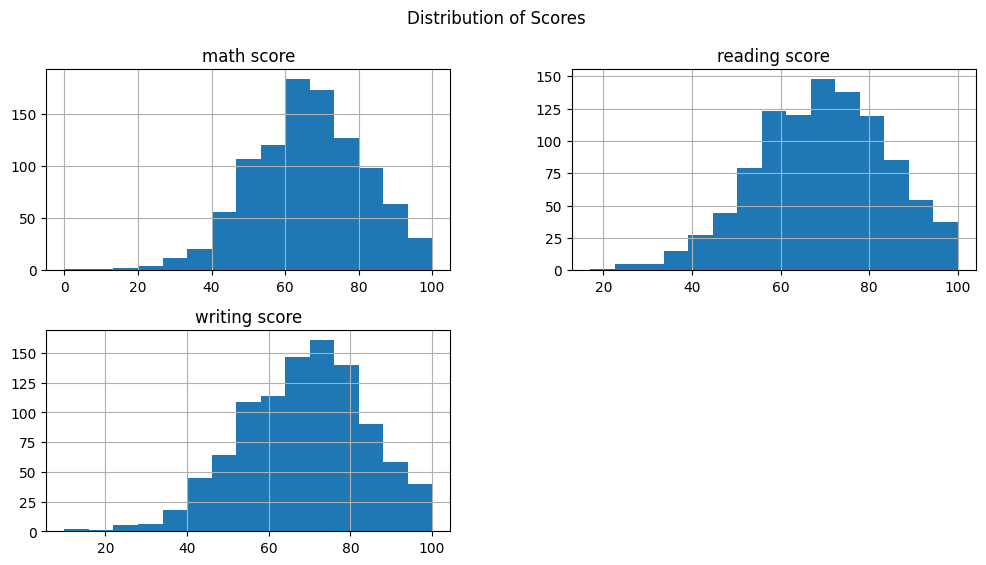

In [ ]:
df=df[["math score", "reading score", "writing score"]].hist(bins=15, figsize=(12, 6))
plt.suptitle("Distribution of Scores")
plt.show()

In [ ]:
correlation = df[["math score", "reading score", "writing score"]].corr()
print(correlation)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


In [ ]:
prep_scores = df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()
print(prep_scores)

                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


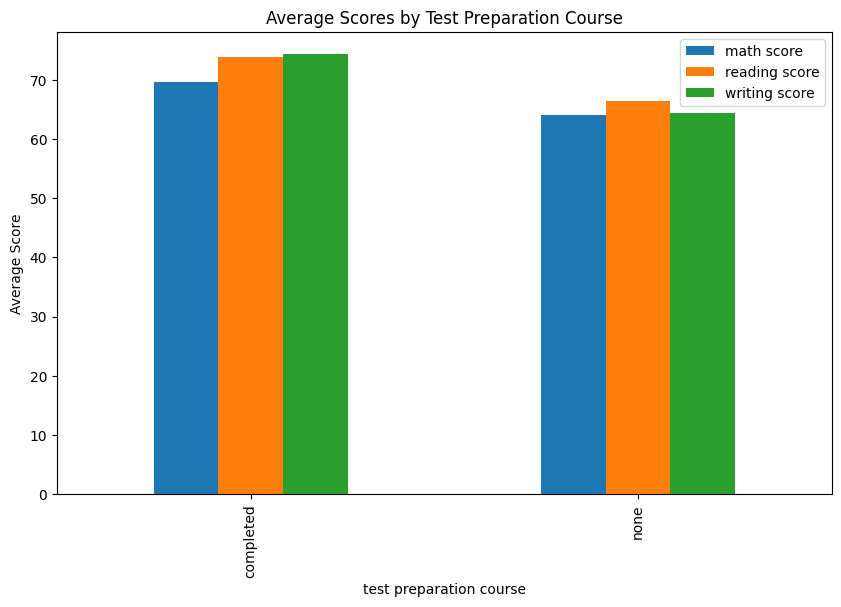

In [ ]:
prep_scores.plot(kind="bar", figsize=(10, 6), title="Average Scores by Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

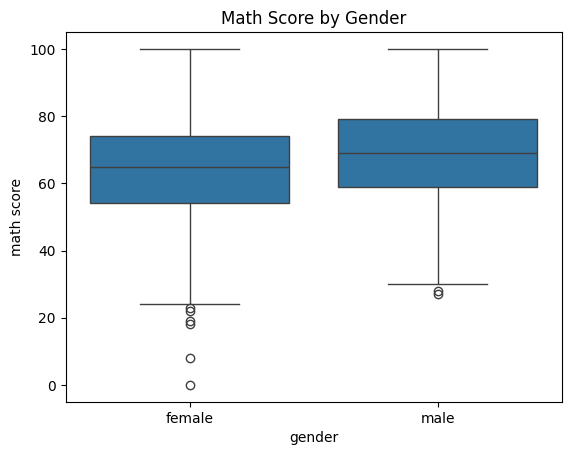

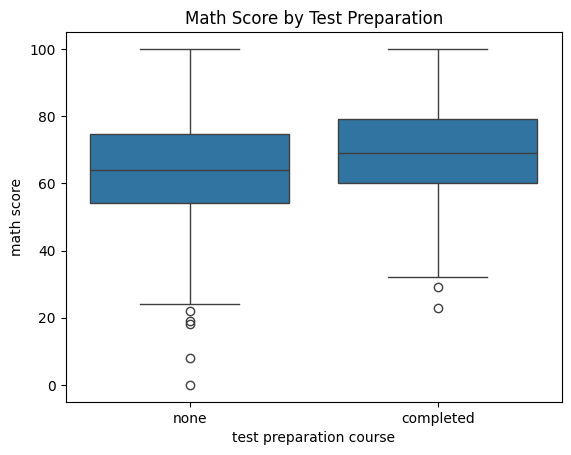

In [ ]:
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Math Score by Gender")
plt.show()

sns.boxplot(x="test preparation course", y="math score", data=df)
plt.title("Math Score by Test Preparation")
plt.show()

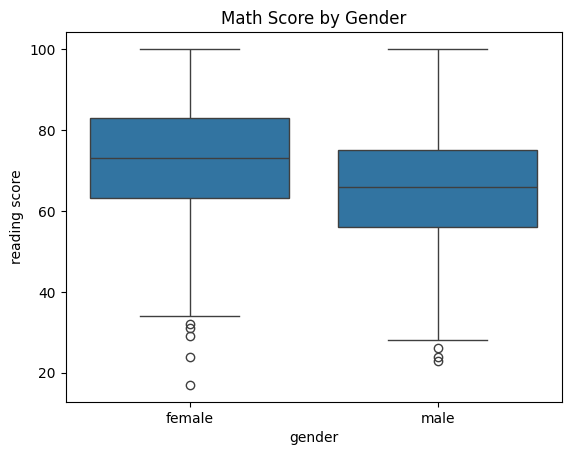

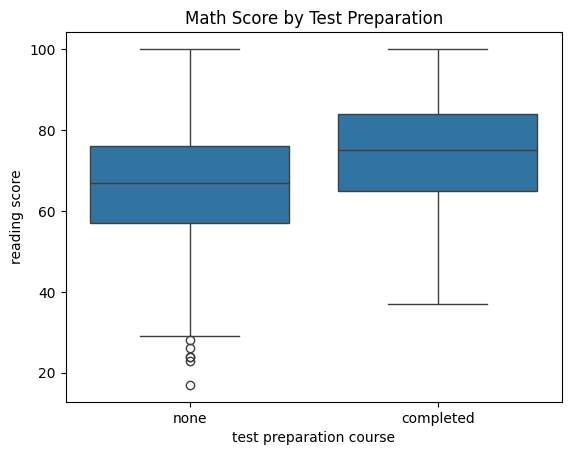

In [ ]:
sns.boxplot(x="gender", y="reading score", data=df)
plt.title("Math Score by Gender")
plt.show()

sns.boxplot(x="test preparation course", y="reading score", data=df)
plt.title("Math Score by Test Preparation")
plt.show()

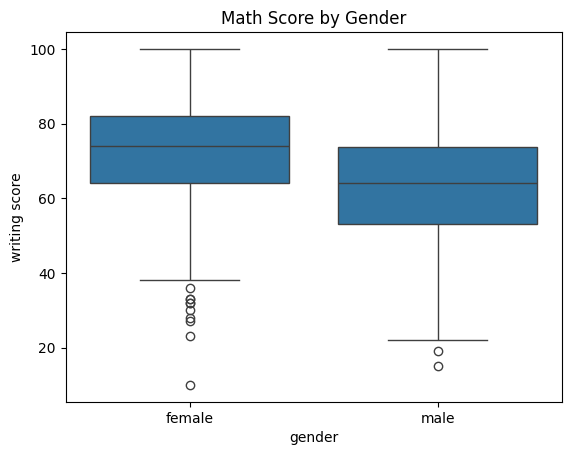

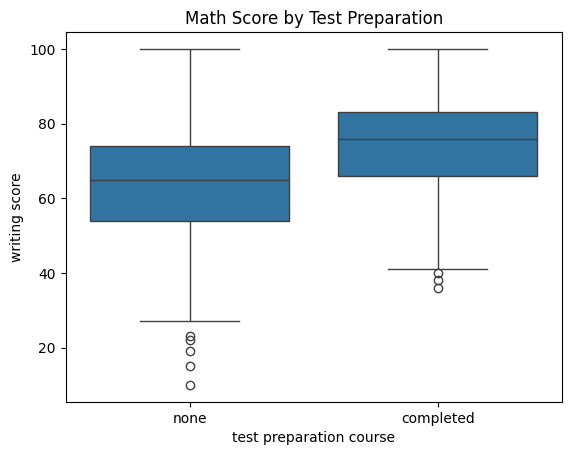

In [ ]:
sns.boxplot(x="gender", y="writing score", data=df)
plt.title("Math Score by Gender")
plt.show()

sns.boxplot(x="test preparation course", y="writing score", data=df)
plt.title("Math Score by Test Preparation")
plt.show()

In [ ]:
grouped_data = df.groupby(['gender', 'race/ethnicity'])[['math score', 'reading score', 'writing score']].mean()
print(grouped_data)

                       math score  reading score  writing score
gender race/ethnicity                                          
female group A          58.527778      69.000000      67.861111
       group B          61.403846      71.076923      70.048077
       group C          62.033333      71.944444      71.777778
       group D          65.248062      74.046512      75.023256
       group E          70.811594      75.840580      75.536232
male   group A          63.735849      61.735849      59.150943
       group B          65.930233      62.848837      60.220930
       group C          67.611511      65.424460      62.712230
       group D          69.413534      66.135338      65.413534
       group E          76.746479      70.295775      67.394366


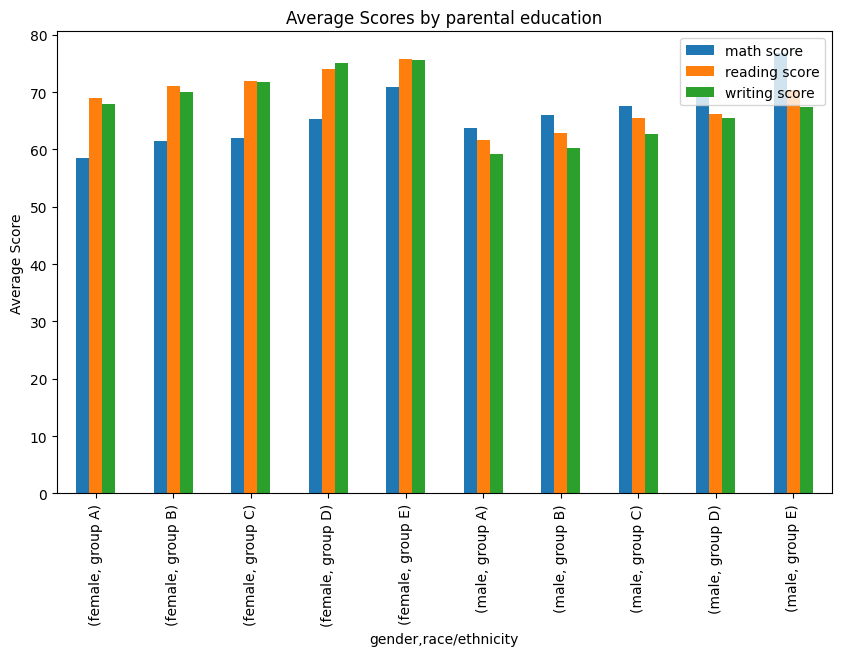

In [ ]:
grouped_data.plot(kind="bar", figsize=(10, 6), title="Average Scores by parental education")
plt.ylabel("Average Score")
plt.show()

In [ ]:
scores_by_gender = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
print(scores_by_gender)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


In [ ]:
#male have more mean score in math
#female has more mean score in reading and writing
#students who have done with test preparation has more score than none
#bachelor degree and master degree parent's childern have high score and least by high school

In [ ]:
#3. Distribution Analysis:
#Visualize score distributions (e.g., histograms, box plots).
#Check for skewness or outliers.

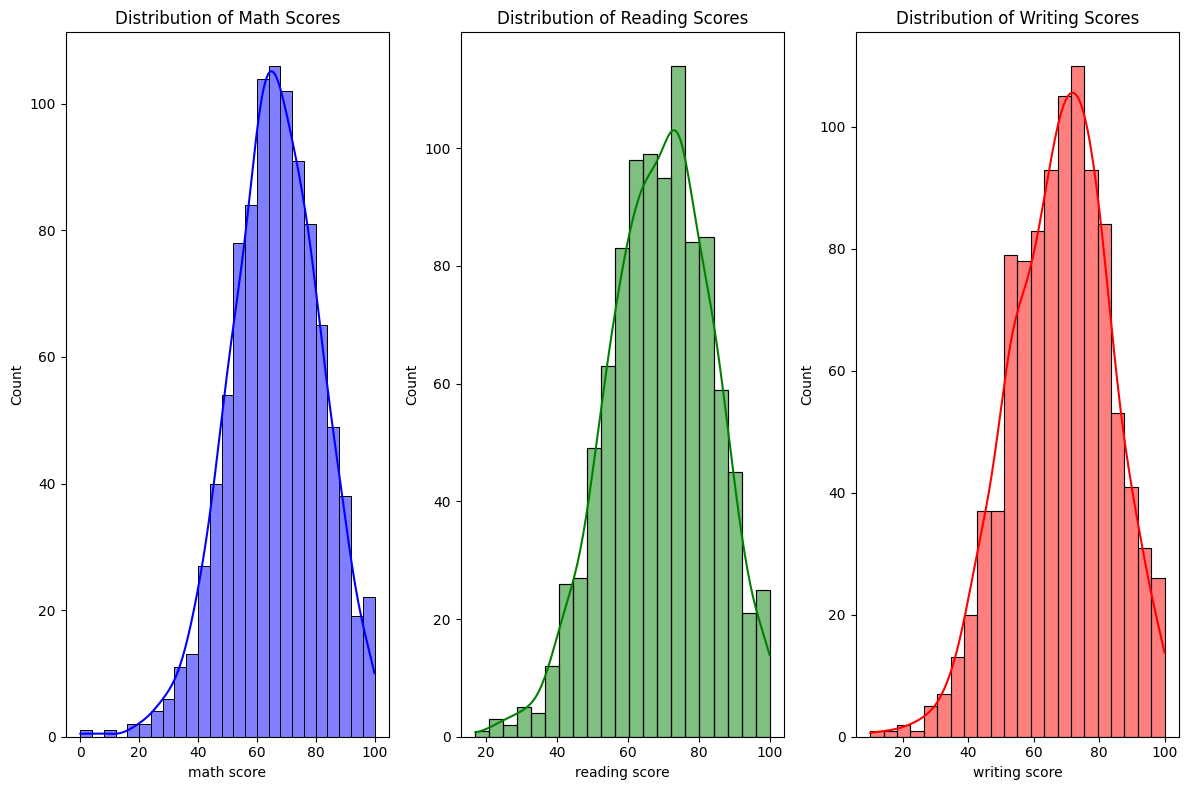

In [ ]:
plt.figure(figsize=(12, 8))

# Math Score Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['math score'], kde=True, color='blue')
plt.title('Distribution of Math Scores')

# Reading Score Histogram
plt.subplot(1, 3, 2)
sns.histplot(df['reading score'], kde=True, color='green')
plt.title('Distribution of Reading Scores')

# Writing Score Histogram
plt.subplot(1, 3, 3)
sns.histplot(df['writing score'], kde=True, color='red')
plt.title('Distribution of Writing Scores')

plt.tight_layout()
plt.show()


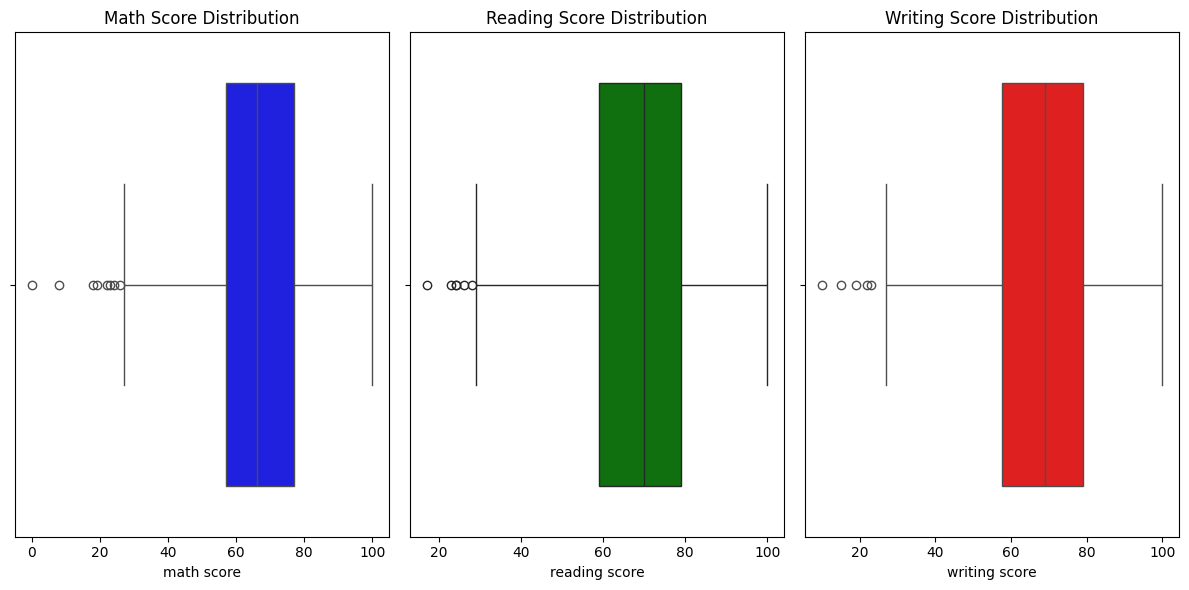

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot for math score
plt.subplot(1, 3, 1)
sns.boxplot(x=df['math score'], color='blue')
plt.title('Math Score Distribution')

# Boxplot for reading score
plt.subplot(1, 3, 2)
sns.boxplot(x=df['reading score'], color='green')
plt.title('Reading Score Distribution')

# Boxplot for writing score
plt.subplot(1, 3, 3)
sns.boxplot(x=df['writing score'], color='red')
plt.title('Writing Score Distribution')

plt.tight_layout()
plt.show()

In [ ]:
print("Math Score Skewness:", df['math score'].skew())
print("Reading Score Skewness:", df['reading score'].skew())
print("Writing Score Skewness:", df['writing score'].skew())

Math Score Skewness: -0.27893514909431694
Reading Score Skewness: -0.25910451810923063
Writing Score Skewness: -0.28944397150761897


In [ ]:
#4. Categorical Analysis:
#Analyze the distribution of categorical variables (gender, lunch, race/ethnicity).
#Create bar charts to compare groups.
import warnings
warnings.filterwarnings('ignore')

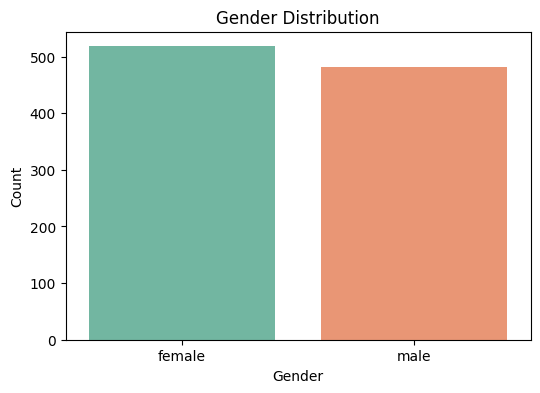

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

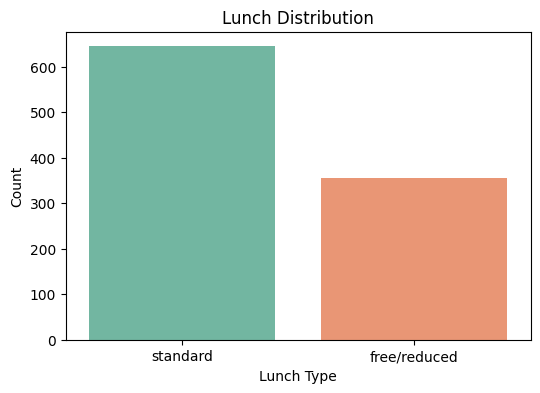

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='lunch', data=df, palette='Set2')
plt.title('Lunch Distribution')
plt.xlabel('Lunch Type')
plt.ylabel('Count')
plt.show()

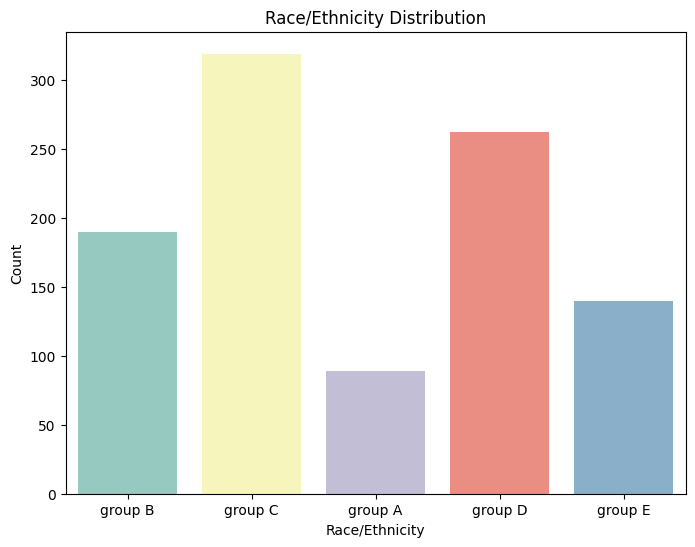

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='race/ethnicity', data=df, palette='Set3')
plt.title('Race/Ethnicity Distribution')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Count')
plt.show()

In [ ]:
#5. Correlations:
#Compute correlation between math score, reading score, and writing score.
#Visualize using a heatmap.

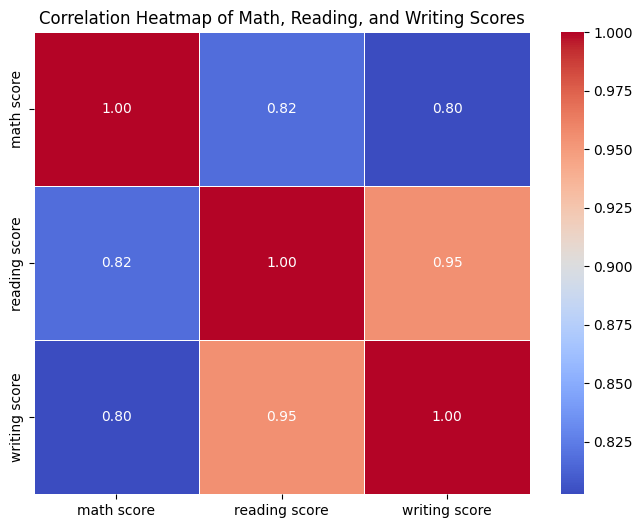

In [ ]:
correlation_matrix = df[['math score', 'reading score', 'writing score']].corr()
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Math, Reading, and Writing Scores')
plt.show()

In [ ]:
#6. Group Comparisons:
#Compare mean scores across categories (gender, test preparation course, etc.).
#Use box plots or violin plots.

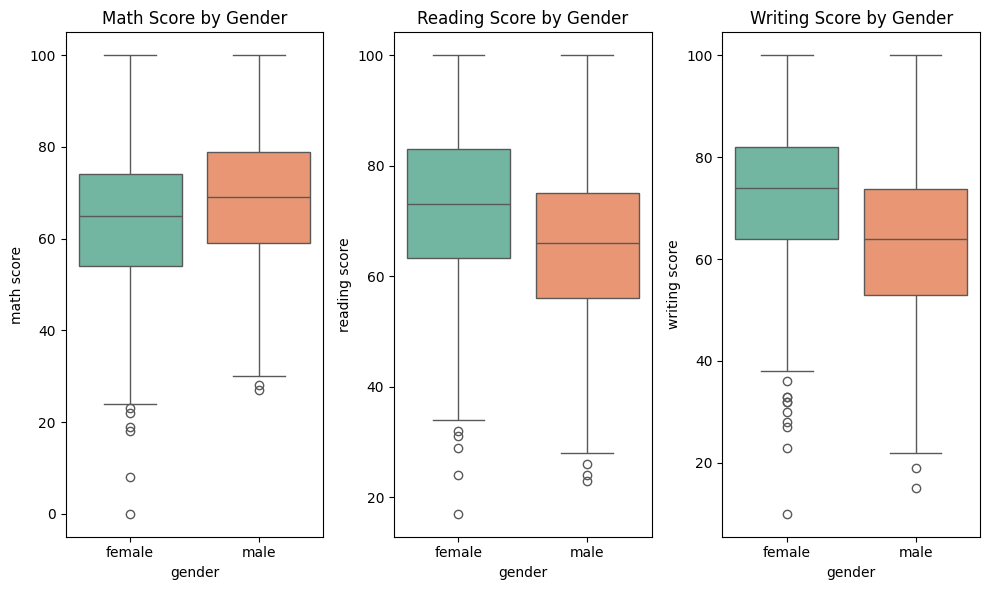

In [ ]:
plt.figure(figsize=(10, 6))

# Math score by gender
plt.subplot(1, 3, 1)
sns.boxplot(x='gender', y='math score', data=df, palette='Set2')
plt.title('Math Score by Gender')

# Reading score by gender
plt.subplot(1, 3, 2)
sns.boxplot(x='gender', y='reading score', data=df, palette='Set2')
plt.title('Reading Score by Gender')

# Writing score by gender
plt.subplot(1, 3, 3)
sns.boxplot(x='gender', y='writing score', data=df, palette='Set2')
plt.title('Writing Score by Gender')

plt.tight_layout()
plt.show()

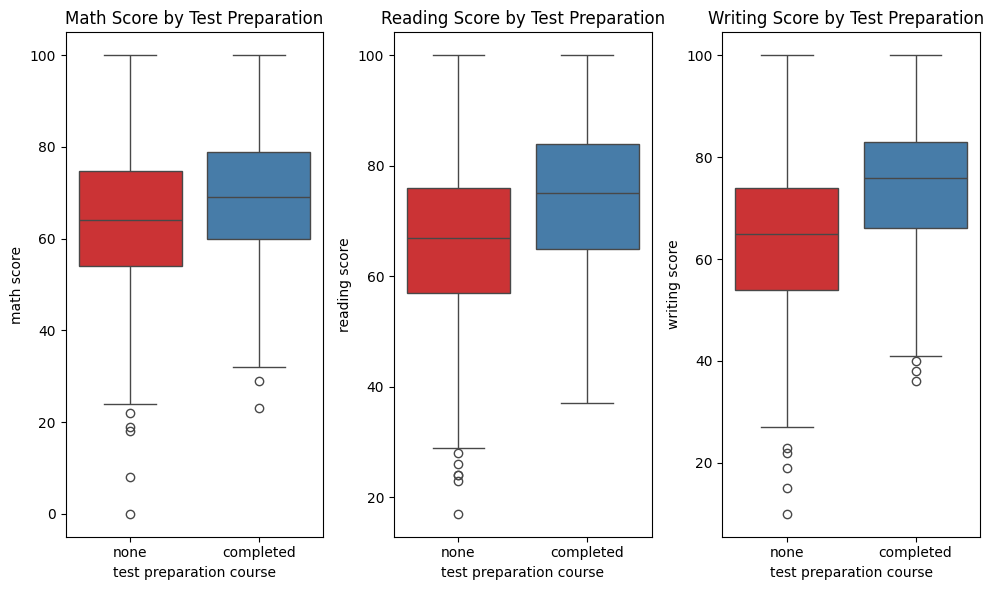

In [ ]:
plt.figure(figsize=(10, 6))

# Math score by test preparation course
plt.subplot(1, 3, 1)
sns.boxplot(x='test preparation course', y='math score', data=df, palette='Set1')
plt.title('Math Score by Test Preparation')

# Reading score by test preparation course
plt.subplot(1, 3, 2)
sns.boxplot(x='test preparation course', y='reading score', data=df, palette='Set1')
plt.title('Reading Score by Test Preparation')

# Writing score by test preparation course
plt.subplot(1, 3, 3)
sns.boxplot(x='test preparation course', y='writing score', data=df, palette='Set1')
plt.title('Writing Score by Test Preparation  ')

plt.tight_layout()
plt.show()


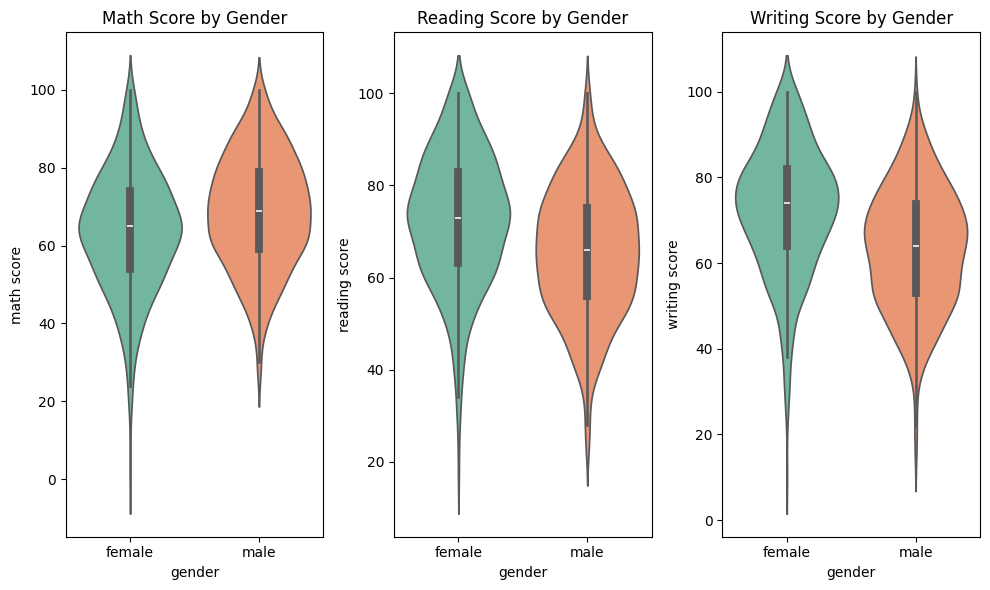

In [ ]:

plt.figure(figsize=(10, 6))

# Math score by gender
plt.subplot(1, 3, 1)
sns.violinplot(x='gender', y='math score', data=df, palette='Set2')
plt.title('Math Score by Gender')

# Reading score by gender
plt.subplot(1, 3, 2)
sns.violinplot(x='gender', y='reading score', data=df, palette='Set2')
plt.title('Reading Score by Gender')

# Writing score by gender
plt.subplot(1, 3, 3)
sns.violinplot(x='gender', y='writing score', data=df, palette='Set2')
plt.title('Writing Score by Gender')

plt.tight_layout()
plt.show()


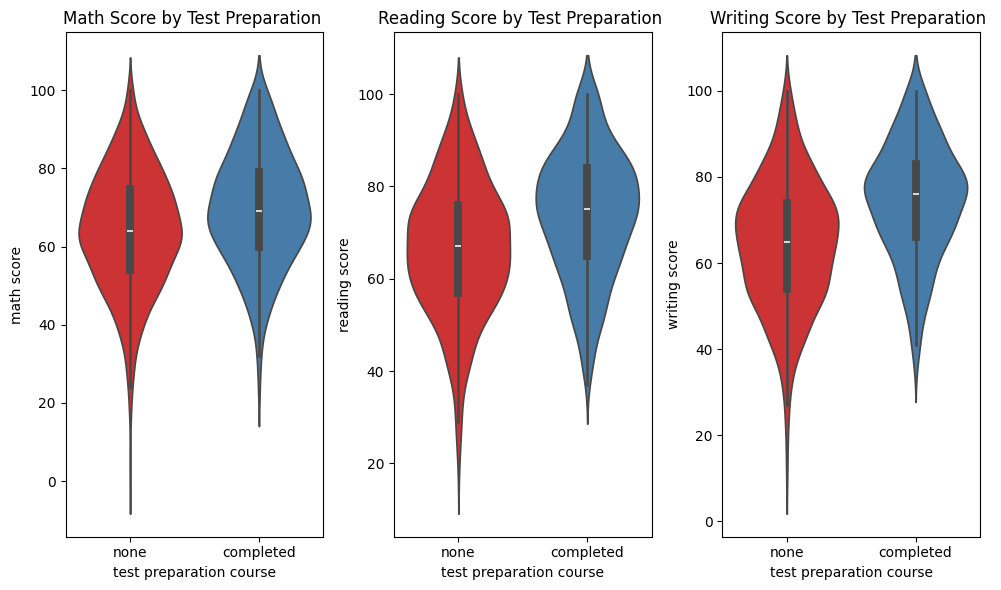

In [ ]:
plt.figure(figsize=(10, 6))

# Math score by test preparation course
plt.subplot(1, 3, 1)
sns.violinplot(x='test preparation course', y='math score', data=df, palette='Set1')
plt.title('Math Score by Test Preparation ')

# Reading score by test preparation course
plt.subplot(1, 3, 2)
sns.violinplot(x='test preparation course', y='reading score', data=df, palette='Set1')
plt.title('Reading Score by Test Preparation ')

# Writing score by test preparation course
plt.subplot(1, 3, 3)
sns.violinplot(x='test preparation course', y='writing score', data=df, palette='Set1')
plt.title('Writing Score by Test Preparation ')

plt.tight_layout()
plt.show()


In [ ]:
#7. Multivariate Analysis:
#Analyze relationships between scores and multiple factors (e.g., scatter plots, pair plots).

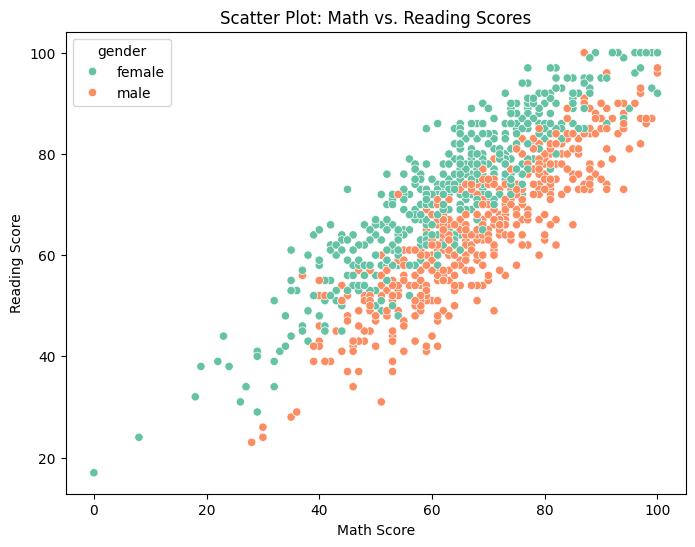

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='math score', y='reading score', data=df, hue='gender', palette='Set2')
plt.title('Scatter Plot: Math vs. Reading Scores')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.show()

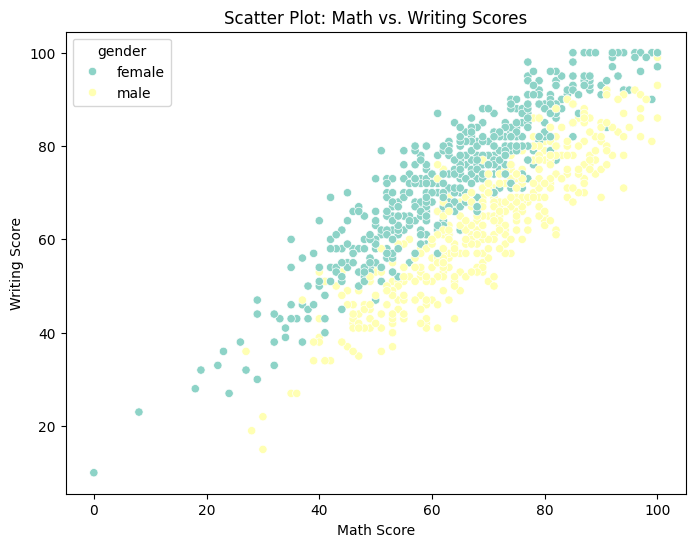

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='math score', y='writing score', data=df, hue='gender', palette='Set3')
plt.title('Scatter Plot: Math vs. Writing Scores')
plt.xlabel('Math Score')
plt.ylabel('Writing Score')
plt.show()

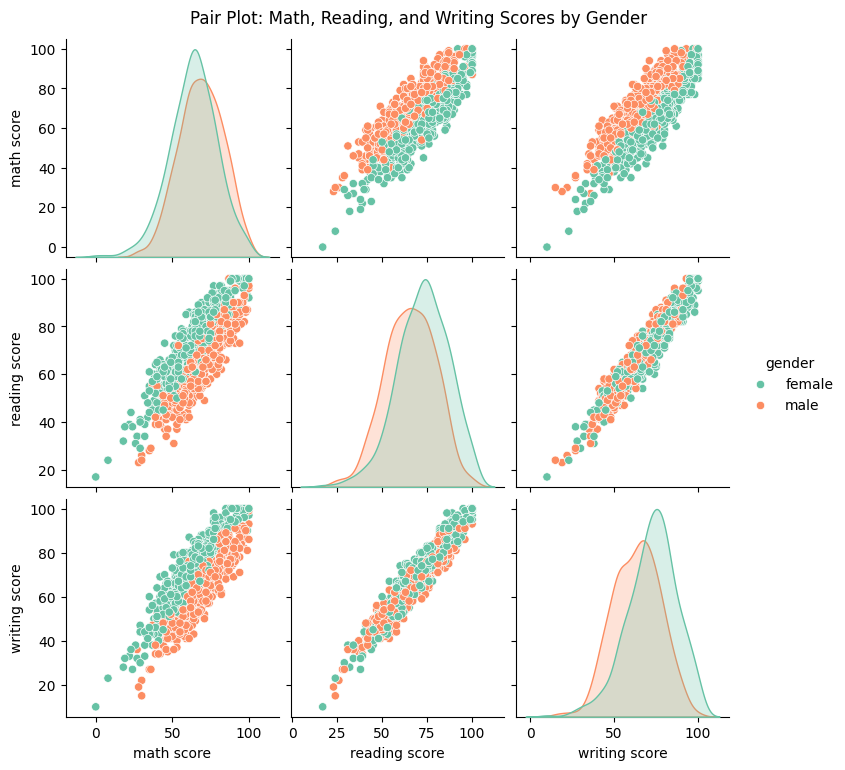

In [ ]:
sns.pairplot(df[['math score', 'reading score', 'writing score', 'gender']], hue='gender', palette='Set2')
plt.suptitle('Pair Plot: Math, Reading, and Writing Scores by Gender', y=1.02)
plt.show()

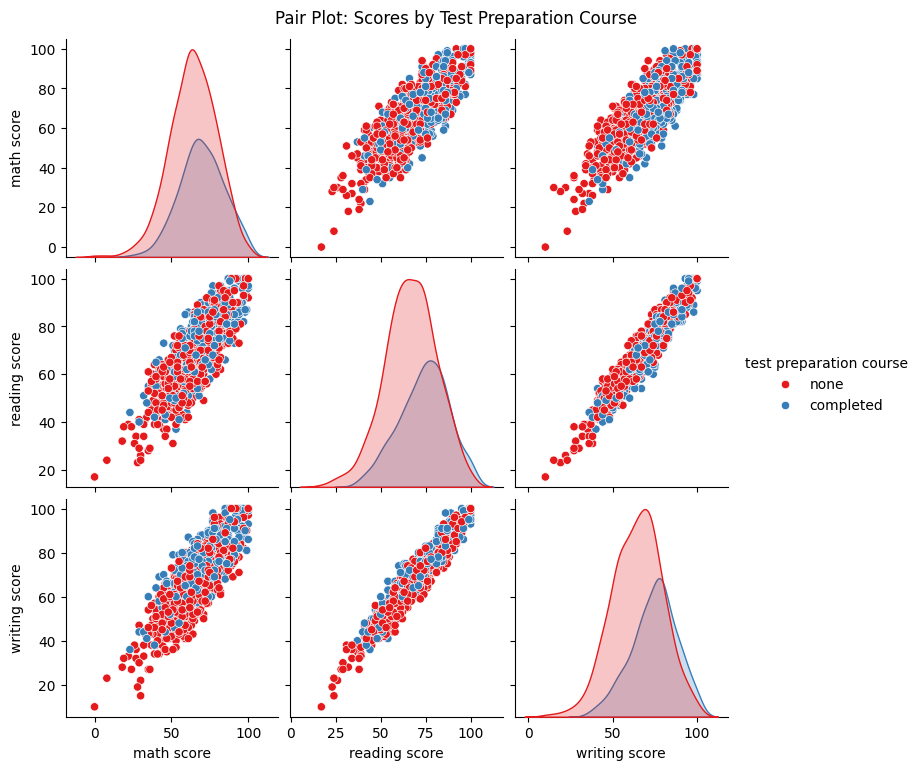

In [ ]:
sns.pairplot(df[['math score', 'reading score', 'writing score', 'test preparation course']],
             hue='test preparation course', palette='Set1')
plt.suptitle('Pair Plot: Scores by Test Preparation Course', y=1.02)
plt.show()


In [ ]:
#8. Insights on Education Impact:
#Examine how parental education level influences scores.
#Compare score averages by parental level of education.


In [ ]:
parents_edu= df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()
print(parents_edu)

                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


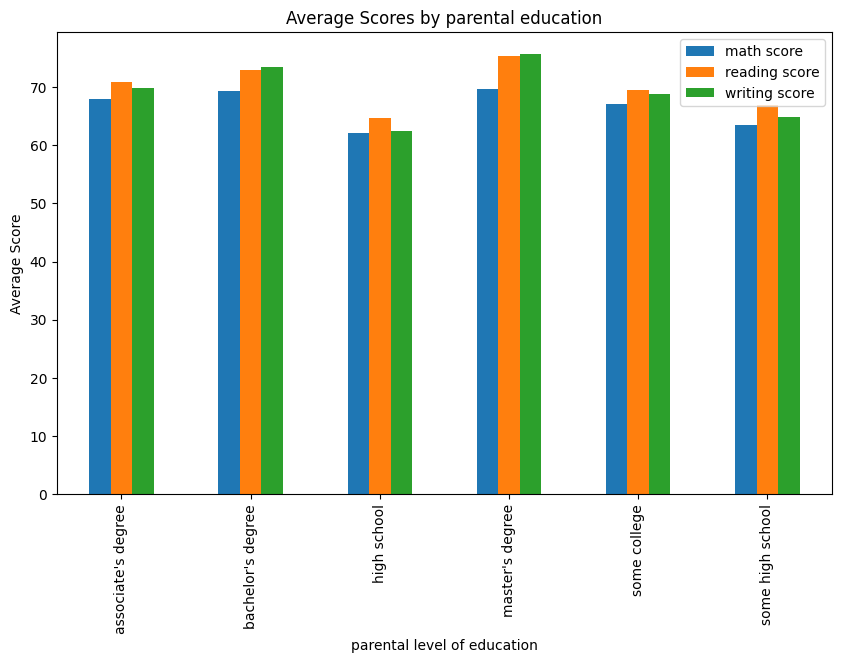

In [ ]:
parents_edu.plot(kind="bar", figsize=(10, 6), title="Average Scores by parental education")
plt.ylabel("Average Score")
plt.show()

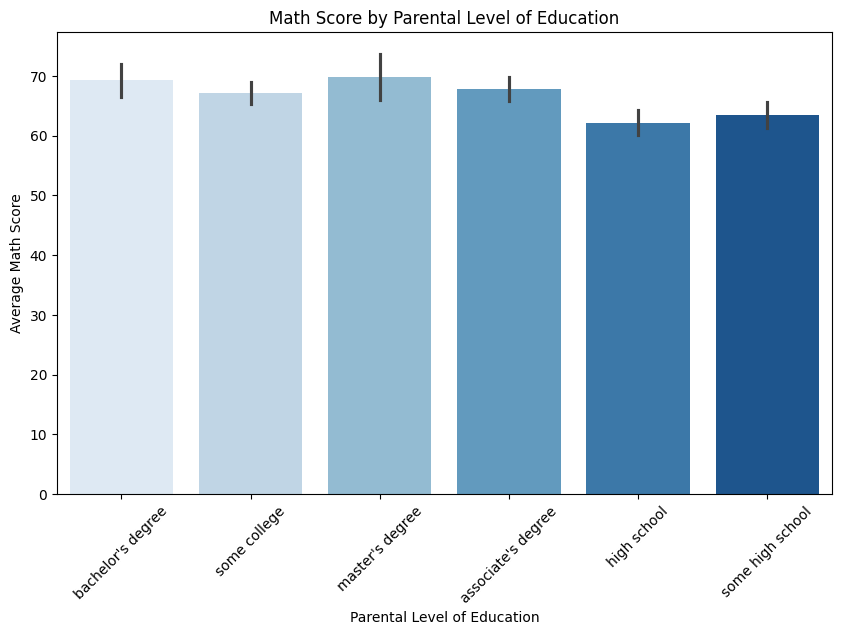

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='parental level of education', y='math score', data=df, palette='Blues')
plt.title('Math Score by Parental Level of Education')
plt.xticks(rotation=45)
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Math Score')
plt.show()

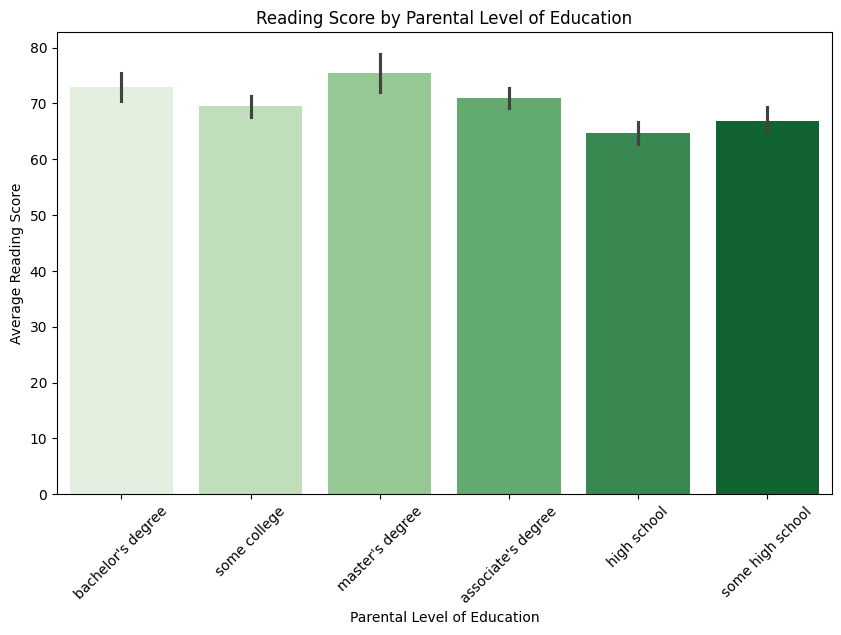

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='parental level of education', y='reading score', data=df, palette='Greens')
plt.title('Reading Score by Parental Level of Education')
plt.xticks(rotation=45)
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Reading Score')
plt.show()

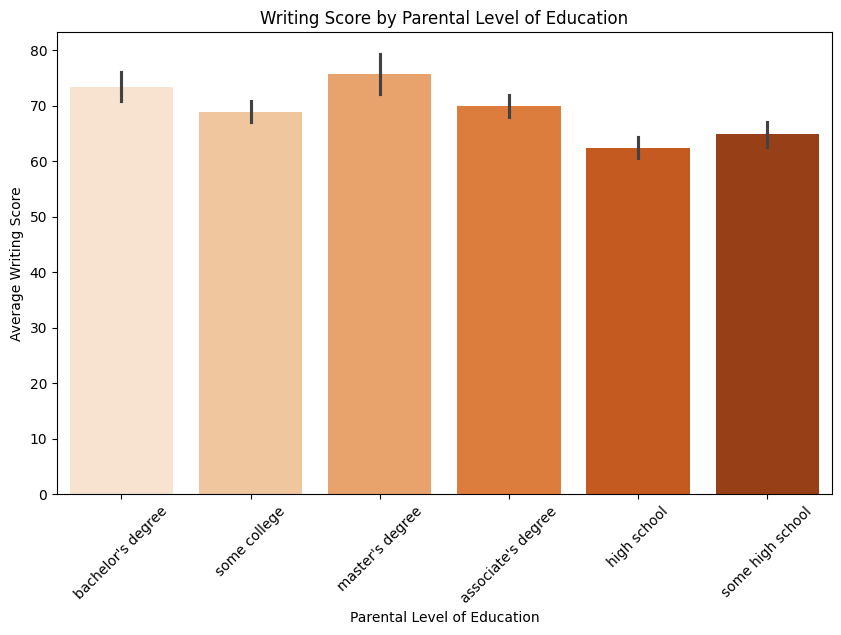

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='parental level of education', y='writing score', data=df, palette='Oranges')
plt.title('Writing Score by Parental Level of Education')
plt.xticks(rotation=45)
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Writing Score')
plt.show()

In [ ]:
students_below35 = df[(df['math score'] < 35) & (df['reading score'] <35) & (df['writing score'] < 35)]
students_below35


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
17,female,group B,some high school,free/reduced,none,18,32,28
59,female,group C,some high school,free/reduced,none,0,17,10
76,male,group E,some high school,standard,none,30,26,22
327,male,group A,some college,free/reduced,none,28,23,19
363,female,group D,some high school,free/reduced,none,27,34,32
596,male,group B,high school,free/reduced,none,30,24,15
601,female,group C,high school,standard,none,29,29,30
980,female,group B,high school,free/reduced,none,8,24,23


In [ ]:
students_above90 = df[(df['math score'] > 95) & (df['reading score'] >95) & (df['writing score'] > 95)]
students_above90

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
114,female,group E,bachelor's degree,standard,completed,99,100,100
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100
458,female,group E,bachelor's degree,standard,none,100,100,100
625,male,group D,some college,standard,completed,100,97,99
712,female,group D,some college,standard,none,98,100,99
717,female,group C,associate's degree,standard,completed,96,96,99
855,female,group B,bachelor's degree,standard,none,97,97,96
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100


In [ ]:
students_above90 .shape

(10, 8)

In [ ]:
students_100 = df[(df['math score']==100) & (df['reading score']==100) & (df['writing score']==100)]
students_100

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
458,female,group E,bachelor's degree,standard,none,100,100,100
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100


In [ ]:
e = df[df['race/ethnicity'] == 'group E']
e

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
32,female,group E,master's degree,free/reduced,none,56,72,65
34,male,group E,some college,standard,none,97,87,82
35,male,group E,associate's degree,standard,completed,81,81,79
44,female,group E,associate's degree,free/reduced,none,50,56,54
50,male,group E,some college,standard,none,53,55,48
...,...,...,...,...,...,...,...,...
962,female,group E,associate's degree,standard,none,100,100,100
968,female,group E,associate's degree,standard,none,68,76,67
987,male,group E,some high school,standard,completed,81,75,76
990,male,group E,high school,free/reduced,completed,86,81,75


In [ ]:
avg_scores = df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()
avg_scores['total average score'] = avg_scores.mean(axis=1)
highest_avg_group = avg_scores['total average score'].idxmax()
print("Group with highest average marks:", highest_avg_group)
print(avg_scores)

Group with highest average marks: group E
                math score  reading score  writing score  total average score
race/ethnicity                                                               
group A          61.629213      64.674157      62.674157            62.992509
group B          63.452632      67.352632      65.600000            65.468421
group C          64.463950      69.103448      67.827586            67.131661
group D          67.362595      70.030534      70.145038            69.179389
group E          73.821429      73.028571      71.407143            72.752381
